In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("hr_data.xls", encoding="utf-8-sig")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [32]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [33]:
print(df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

(1470, 35)
Missing values: 0
Duplicate rows: 0


### Data Preprocessing & Exploratory Data Analysis (EDA)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


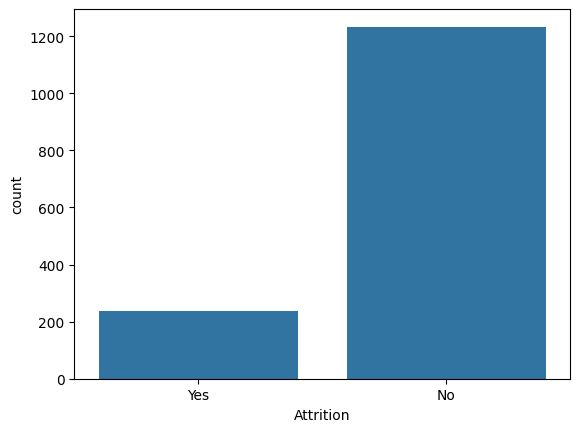

In [34]:
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True))
sns.countplot(data=df, x="Attrition")
plt.show()

In [35]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [36]:
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
print(df.shape)

(1470, 31)


In [37]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(cat_cols)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [46]:
for col in cat_cols:
    print(df.groupby(col)["Attrition"].mean().sort_values(ascending=False).round(3))
    print()

BusinessTravel
Travel_Frequently    0.249
Travel_Rarely        0.150
Non-Travel           0.080
Name: Attrition, dtype: float64

Department
Sales                     0.206
Human Resources           0.190
Research & Development    0.138
Name: Attrition, dtype: float64

EducationField
Human Resources     0.259
Technical Degree    0.242
Marketing           0.220
Life Sciences       0.147
Medical             0.136
Other               0.134
Name: Attrition, dtype: float64

Gender
Male      0.170
Female    0.148
Name: Attrition, dtype: float64

JobRole
Sales Representative         0.398
Laboratory Technician        0.239
Human Resources              0.231
Sales Executive              0.175
Research Scientist           0.161
Manufacturing Director       0.069
Healthcare Representative    0.069
Manager                      0.049
Research Director            0.025
Name: Attrition, dtype: float64

MaritalStatus
Single      0.255
Married     0.125
Divorced    0.101
Name: Attrition, dtype: float64

In [47]:
num_cols = df.select_dtypes(include="number").columns.drop("Attrition").tolist()
print(df.groupby("Attrition")[num_cols].mean().T.round(2))

Attrition                        0         1
Age                          37.56     33.61
DailyRate                   812.50    750.36
DistanceFromHome              8.92     10.63
Education                     2.93      2.84
EnvironmentSatisfaction       2.77      2.46
HourlyRate                   65.95     65.57
JobInvolvement                2.77      2.52
JobLevel                      2.15      1.64
JobSatisfaction               2.78      2.47
MonthlyIncome              6832.74   4787.09
MonthlyRate               14265.78  14559.31
NumCompaniesWorked            2.65      2.94
PercentSalaryHike            15.23     15.10
PerformanceRating             3.15      3.16
RelationshipSatisfaction      2.73      2.60
StockOptionLevel              0.85      0.53
TotalWorkingYears            11.86      8.24
TrainingTimesLastYear         2.83      2.62
WorkLifeBalance               2.78      2.66
YearsAtCompany                7.37      5.13
YearsInCurrentRole            4.48      2.90
YearsSince

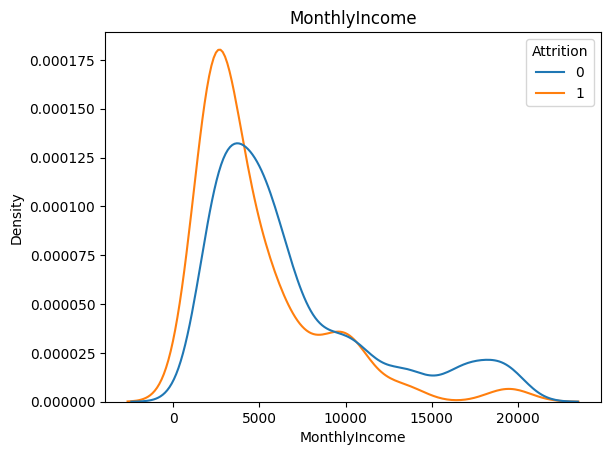

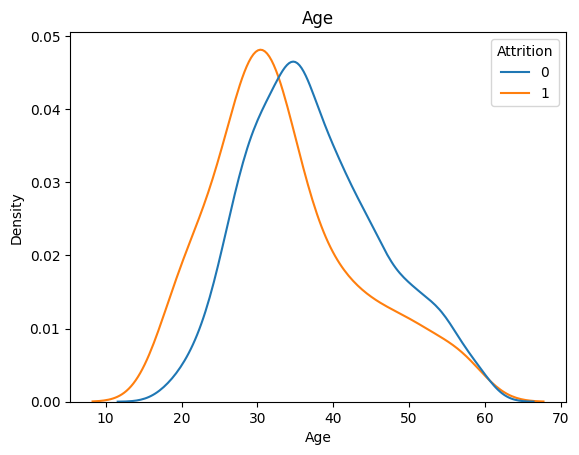

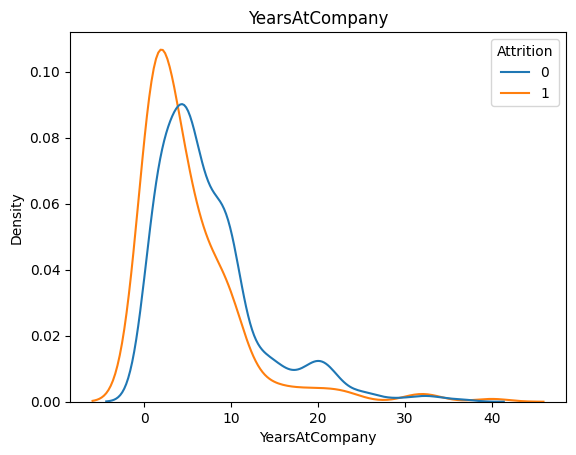

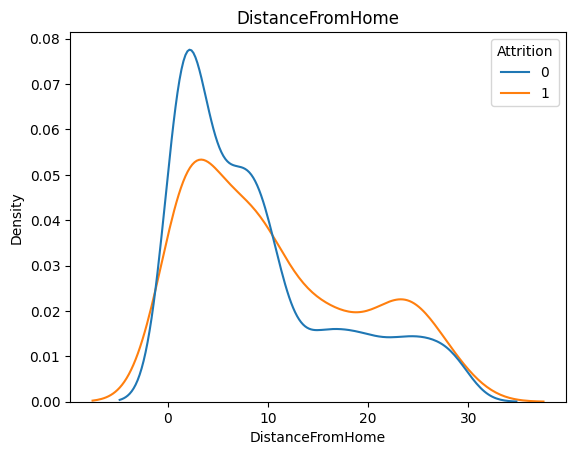

In [48]:
for col in ["MonthlyIncome", "Age", "YearsAtCompany", "DistanceFromHome"]:
    sns.kdeplot(data=df, x=col, hue="Attrition", common_norm=False)
    plt.title(col)
    plt.show()

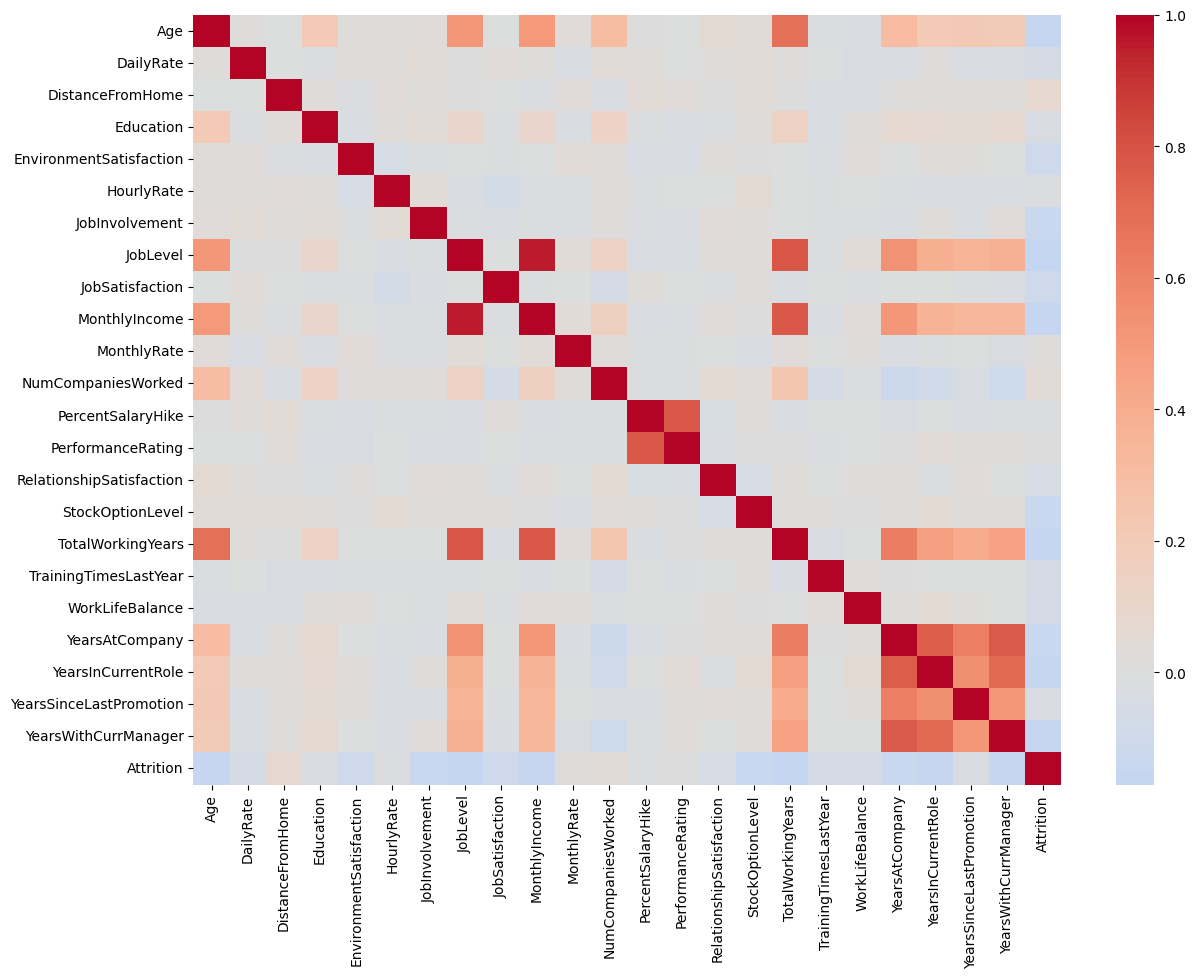

In [45]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols + ["Attrition"]].corr(), cmap="coolwarm", center=0)
plt.show()

In [51]:
df.groupby( 'OverTime')["Attrition"].mean()

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64

Model Training & AutoML

In [53]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1176, 30) (294, 30)


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [61]:
cat_cols =X.select_dtypes(include='object').columns.to_list
num_cols  = X.select_dtypes(include='number').columns.to_list

num_pipe= Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])


cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mostfrequent')),
    ('oneHot',OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
])

In [63]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
models={
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest" : RandomForestClassifier(n_estimators=300, class_weight='balanced')
}
for name,clf in models.items():
   pipe = Pipeline([('prep',preprocessor),('model',clf)])
   pipe.fit(X_train, y_train)
   pred  = pipe.predict(X_test)
   proba = pipe.predict_proba(X_test)[:, 1]
 print(classification_report(y_test, pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

SyntaxError: invalid syntax (67058159.py, line 6)